# AMS 518. Homework 7

# Juan Perez Osorio - SBU ID: 116248538

## Problem 1

1. Download dataset from the following case study:

PROBLEM 1: 10-fold Cross-validation (10 in-sample data and 10 out-of-sample data) for Standard Deviation minimization

https://uryasev.ams.stonybrook.edu/research/testproblems/financial_engineering/mortgage-pipeline-hedging/

Modify the code and input data to perform 5-fold cross-validation.



First I need to modify the problem statement in the text file:

~~~R
"""for {matrix_fact_in; matrix_fact_out; num} = crossvalidation(5, matrix_scenarios)

minimize 
st_dev(matrix_fact_in)
Value: 
  L_num(matrix_fact_out) 
  L_num(matrix_fact_in)
  cvar_dev(0.9, matrix_fact_in) meanabs_dev(matrix_fact_in)
  st_dev(matrix_fact_in)
  var_risk(0.75, matrix_fact_in)
  var_risk_g(0.75, matrix_fact_in)
  var_risk(0.9, matrix_fact_in)
  var_risk_g(0.9, matrix_fact_in)    
end for""" 
~~~                                                                       


After running the problem in the PSG.exe solver we obtain the following results:

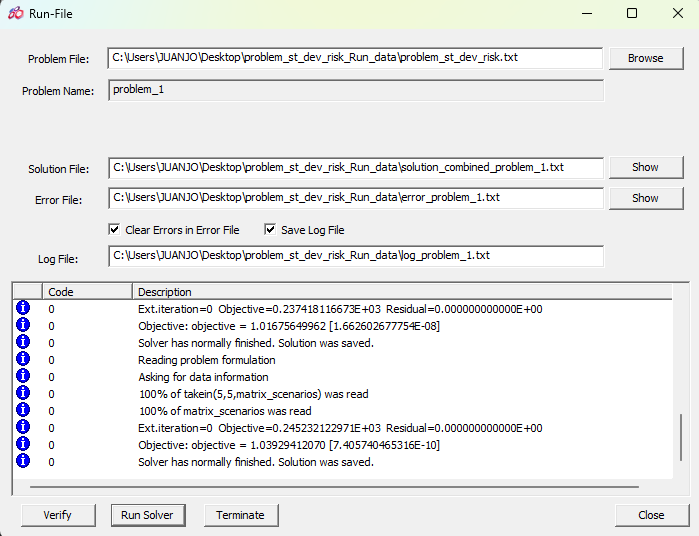

In [2]:
from IPython.display import Image
display(Image(filename='data/problem_1.png')) 

## Problem 2

We start as usual by downloading the data and setting up our working directory in RStudio

~~~R
setwd("C:/Users/Jujop/Documents/GitHub/ams-518/homework-7/data")

# Set path to Rdata file including the RData file's name with CS:
load("C:/Users/Jujop/Documents/GitHub/ams-518/
            homework-7/data/problem_st_dev_risk.RData")
~~~

Now we check the existing data file to see what's currently in there

~~~R
# Check what is the current problem statement
> problem.list$problem_statement
 [1] "for {matrix_fact_in; matrix_fact_out; num} = 
            crossvalidation(10, matrix_scenarios)"
 [2] "minimize"                                                                          
 [3] "st_dev(matrix_fact_in)"                                                            
 [4] "Value:"                                                                            
 [5] "L_num(matrix_fact_out)"                                                            
 [6] "L_num(matrix_fact_in)"                                                             
 [7] "cvar_dev(0.9, matrix_fact_in) meanabs_dev(matrix_fact_in)"                         
 [8] "st_dev(matrix_fact_in)"                                                            
 [9] "var_risk(0.75, matrix_fact_in)"                                                    
[10] "var_risk_g(0.75, matrix_fact_in)"                                                  
[11] "var_risk(0.9, matrix_fact_in)"                                                     
[12] "var_risk_g(0.9, matrix_fact_in)"                                                   
[13] "end for"
~~~

We see that we should modify the second entry on the problem statement since we need to perform CVaR regression. Also, we replace standard deviation by CVaR deviation with confidence level 0.95

~~~R
# Modify the problem statement
problem.list$problem_statement <- list()
problem.list$problem_statement[1] <- "minimize"
problem.list$problem_statement[2] <- "cvar_dev(0.95,matrix_fact_in)"
problem.list$problem_statement[3] <- "Value:"
problem.list$problem_statement[4] <- "cvar_dev(0.95,matrix_fact_out)"
~~~

2. We need to pick 2 factors (in my case last name: Perez) $x_2$ and $x_3$

Now, I need to perform the following steps

* **I.** Randomly select 100 rows from the 1000 rows as the testing set.
* **II.** Randomly select 3 rows from the remaining 900 rows as the training set.
* **III.** Fit the two-factor model and three-factor model with the training set; obtain in-sample CVaR deviation.
* **IV.** Calculate the out-of-sample CVaR deviation of the two models on the testing set.
* **V.** Repeat steps I–IV at least 20 times and calculate the average of CVaR deviations for both in-sample and out-of-sample values.
* **VI.** Repeat steps I–V with different numbers of rows in step II; the suggested numbers are 20, 40, 60, ..., 880, 900.

for this, I have implemented the following algorithm in R that does all this simulations for 25 times in step V and I choose to repeat it on the specified frequency in step VI. The only modification is that when performing the 5-fold validation with only 3 rows (first case), the PSG solver gives me an error since it doesn't have enough data to perform the splits and validation, hence I have switched the minimum number of rows from 3 to 5, and I also include two intermediate steps of 10 and 15 rows, after that I consider the same sequence of suggested rows: 20, 40, 60, ..., 880, 900. 

The algorithm in R is shown below

~~~R
# Extract the original 3-factor matrix (e.g., 1000 rows, 4 cols)
matrix_scenarios_3fact <- problem.list$matrix_scenarios

# Last name: Perez, hence I should pick variables x2 and x3
matrix_scenarios_2fact <- matrix_scenarios_3fact[, c(2, 3, 4)]

# Set up our simulation parameters

# Create a sequence of training sizes of 5, 10, 15, 20, 40, 60, ..., 900
training_sizes <- c(5, 10, 15, seq(20, 900, by = 20))

# Number of times we are going to run each simulation (minimum = 20)
n_repetitions <- 25

# Total number of rows
n_total_rows <- nrow(matrix_scenarios_3fact)

# Testing set will always contain 100 rows
n_test <- 100

all_indices <- 1:n_total_rows

# Initialize the results storage
# This data frame will store the final average for each training size
results_df <- data.frame(
  TrainingSize = integer(),
  # 2-Factor CVaR In-Sample
  Avg_InSample_2F = double(), # CVaR in sample
  
  # 2-Factor CVaR Out-of-Sample
  Avg_OutOfSample_2F = double(), # CVaR out of sample
  
  # 3-Factor CVaR In-Sample
  Avg_InSample_3F = double(), # CVaR in sample
  
  # 3-Factor Out-of-Sample
  Avg_OutOfSample_3F= double() # CVaR out of sample
)

# Initialize the problem lists
problem.list.in.2f <- problem.list # Use the existing problem.list
problem.list.in.3f <- problem.list # Use the existing problem.list

# Outer loop: to iterate over each training size
for (n_train in training_sizes) {
  
  print(paste("Starting Training Size:", n_train))
  
  # Temporary matrices to store the average vectors from each rep
  # Matrix: (n_repetitions x 2 factors)
  in_sample_2f_reps <- matrix(NA, nrow = n_repetitions, ncol = 1)
  # Matrix: (n_repetitions x 3 factors)
  in_sample_3f_reps <- matrix(NA, nrow = n_repetitions, ncol = 1)
  
  # Temporary vectors to store results for the 30 repetitions
  out_sample_2f_reps <- matrix(NA, nrow = n_repetitions, ncol = 1)
  out_sample_3f_reps <- matrix(NA, nrow = n_repetitions, ncol = 1)
  
  # Repeat the experiment 30 times
  for (i in 1:n_repetitions) {
    
    # Step I: Randomly select 100 rows for testing set
    test_indices <- sample(all_indices, n_test)
    remaining_indices <- setdiff(all_indices, test_indices) # 900 remaining
    
    # Step II: Randomly select n_train rows from remaining
    train_indices <- sample(remaining_indices, n_train)
    
    # Create the training and testing matrices for this iteration
    matrix_train_set_3f <- matrix_scenarios_3fact[train_indices, ]
    matrix_test_set_3f  <- matrix_scenarios_3fact[test_indices, ]
    
    matrix_train_set_2f <- matrix_scenarios_2fact[train_indices, ]
    matrix_test_set_2f  <- matrix_scenarios_2fact[test_indices, ]
    
    #Step III and IV: Fit models and get In-Sample and Out of sample CVaR Deviation
    
    # 2-Factor In-Sample
    
    # Modify the first entry of the statement
    problem.list.in.2f$matrix_fact_in <- matrix_train_set_2f
    problem.list.in.2f$matrix_fact_out <- matrix_test_set_2f
    
    # Generate output for 2 factor model
    output_2f <- rpsg_solver(problem.list.in.2f)
    
    # Extract the CVaR value 
    cvar_in_2f <- output_2f$output[5]
    cvar_in_2f <- strsplit(cvar_in_2f, "=")[[1]]
    cvar_in_2f <- as.numeric(trimws(cvar_in_2f[2]))
    
    cvar_out_2f <- output_2f$output[6]
    cvar_out_2f <- strsplit(cvar_out_2f, "=")[[1]]
    cvar_out_2f <- as.numeric(trimws(cvar_out_2f[2]))
    
    # Fill in the averaged values
    in_sample_2f_reps[i,] <- cvar_in_2f
    out_sample_2f_reps[i, ] <- cvar_out_2f
    
    # 3-Factor In-Sample
    
    # Modify the first entry of the statement
    problem.list.in.3f$matrix_fact_in <- matrix_train_set_3f
    problem.list.in.3f$matrix_fact_out <- matrix_test_set_3f
    
    output_3f <- rpsg_solver(problem.list.in.3f)
    
    # Extract the CVaR value 
    cvar_in_3f <- output_3f$output[5]
    cvar_in_3f <- strsplit(cvar_in_3f, "=")[[1]]
    cvar_in_3f <- as.numeric(trimws(cvar_in_3f[2]))
    
    cvar_out_3f <- output_3f$output[6]
    cvar_out_3f <- strsplit(cvar_out_3f, "=")[[1]]
    cvar_out_3f <- as.numeric(trimws(cvar_out_3f[2]))
    
    # Fill in the averaged values
    in_sample_3f_reps[i,] <- cvar_in_3f
    out_sample_3f_reps[i, ] <- cvar_out_3f
    
  } # End of middle loop (n_repetitions)
  
  # Step V: Calculate averages
  avg_in_2f  <- colMeans(in_sample_2f_reps, na.rm = TRUE)
  avg_in_3f  <- colMeans(in_sample_3f_reps, na.rm = TRUE)
  
  avg_out_2f  <- colMeans(out_sample_2f_reps, na.rm = TRUE)
  avg_out_3f  <- colMeans(out_sample_3f_reps, na.rm = TRUE)
  
  # Store the averages in the main results data frame
  results_df <- rbind(results_df, data.frame(
    TrainingSize = n_train,
    Avg_InSample_2F = avg_in_2f[1], # Corresponds to CVaR in Sample 2F
    Avg_OutOfSample_2F = avg_out_2f[1], # Corresponds to CVaR our of Sample 2F
    
    Avg_InSample_3F = avg_in_3f[1], # Corresponds to CVaR in Sample 3F
    Avg_OutOfSample_3F = avg_out_3f[1] # Corresponds to CVaR out of Sample 3F
  ))
} # End of outer loop (training_sizes)

# Final Results
print("Simulation Complete. Final averaged results:")
print(results_df)
~~~

After running the algorithm, the results obtained are structured as follows:

~~~R
> head(results_df)
  TrainingSize Avg_InSample_2F Avg_OutOfSample_2F Avg_InSample_3F
1            5       0.1361037           5.014555      0.01784731
2           10       0.4709814           3.773400      0.22232188
3           15       0.3627785           2.731599      0.15371176
4           20       0.5444694           3.076404      0.31870287
5           40       0.7542827           1.805169      0.38082920
6           60       0.8136983           1.784707      0.41621443
  Avg_OutOfSample_3F
1           6.645222
2           6.362930
3           2.995804
4           3.269787
5           1.072823
6           0.974827
~~~

3. Build a graph using the results computed in the previous question, similar to “Figure 4: Performance of models with different flexibility” in Module 7 Notes.

To graph it we reshape the obtained results and prepare the data for being plotted.

~~~R
# Reshape data for ggplot2
# "Melt" the data frame from wide to long format for ggplot
# This creates a single column for the 'Metric' and 'CVaR_Value'

results_long <- results_df %>%
  pivot_longer(
    cols = c("Avg_InSample_2F", "Avg_OutOfSample_2F", 
              "Avg_InSample_3F", "Avg_OutOfSample_3F"),
    names_to = "Metric",
    values_to = "CVaR_Deviation"
  ) %>%
  # Create helper columns for Model and Sample Type based on the Metric name
  mutate(
    Model = ifelse(grepl("2F", Metric), 
              "2-Factor (Less Flexible)", "3-Factor (More Flexible)"),
    SampleType = ifelse(grepl("InSample", Metric), "In-Sample", "Out-of-Sample")
  )

~~~

We can see that Figure 4. contains the following representations:

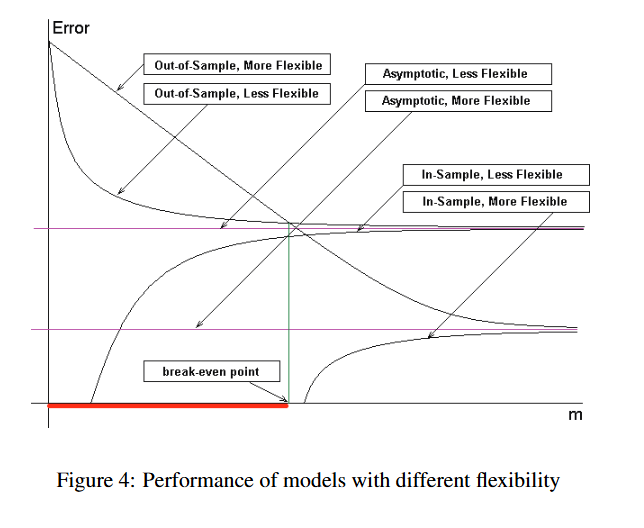

In [3]:
from IPython.display import Image
display(Image(filename='data/figure4.png')) 

We can see that this graph illustrates the conceptual relationship between model flexibility, data size, and error. 

It plots the prediction error (vertical axis) against the training set size (horizontal axis) for two different models: a less flexible model and a more flexible model. The graph clearly shows that while the more flexible model achieves a lower training error, its test error is high for small datasets due to overfitting. The less flexible model performs better on small datasets. 

The crossover point shows that the more flexible model only becomes superior (achieves a lower test error) after a sufficient amount of training data is available.

Let's see how our version of this graph looks like 

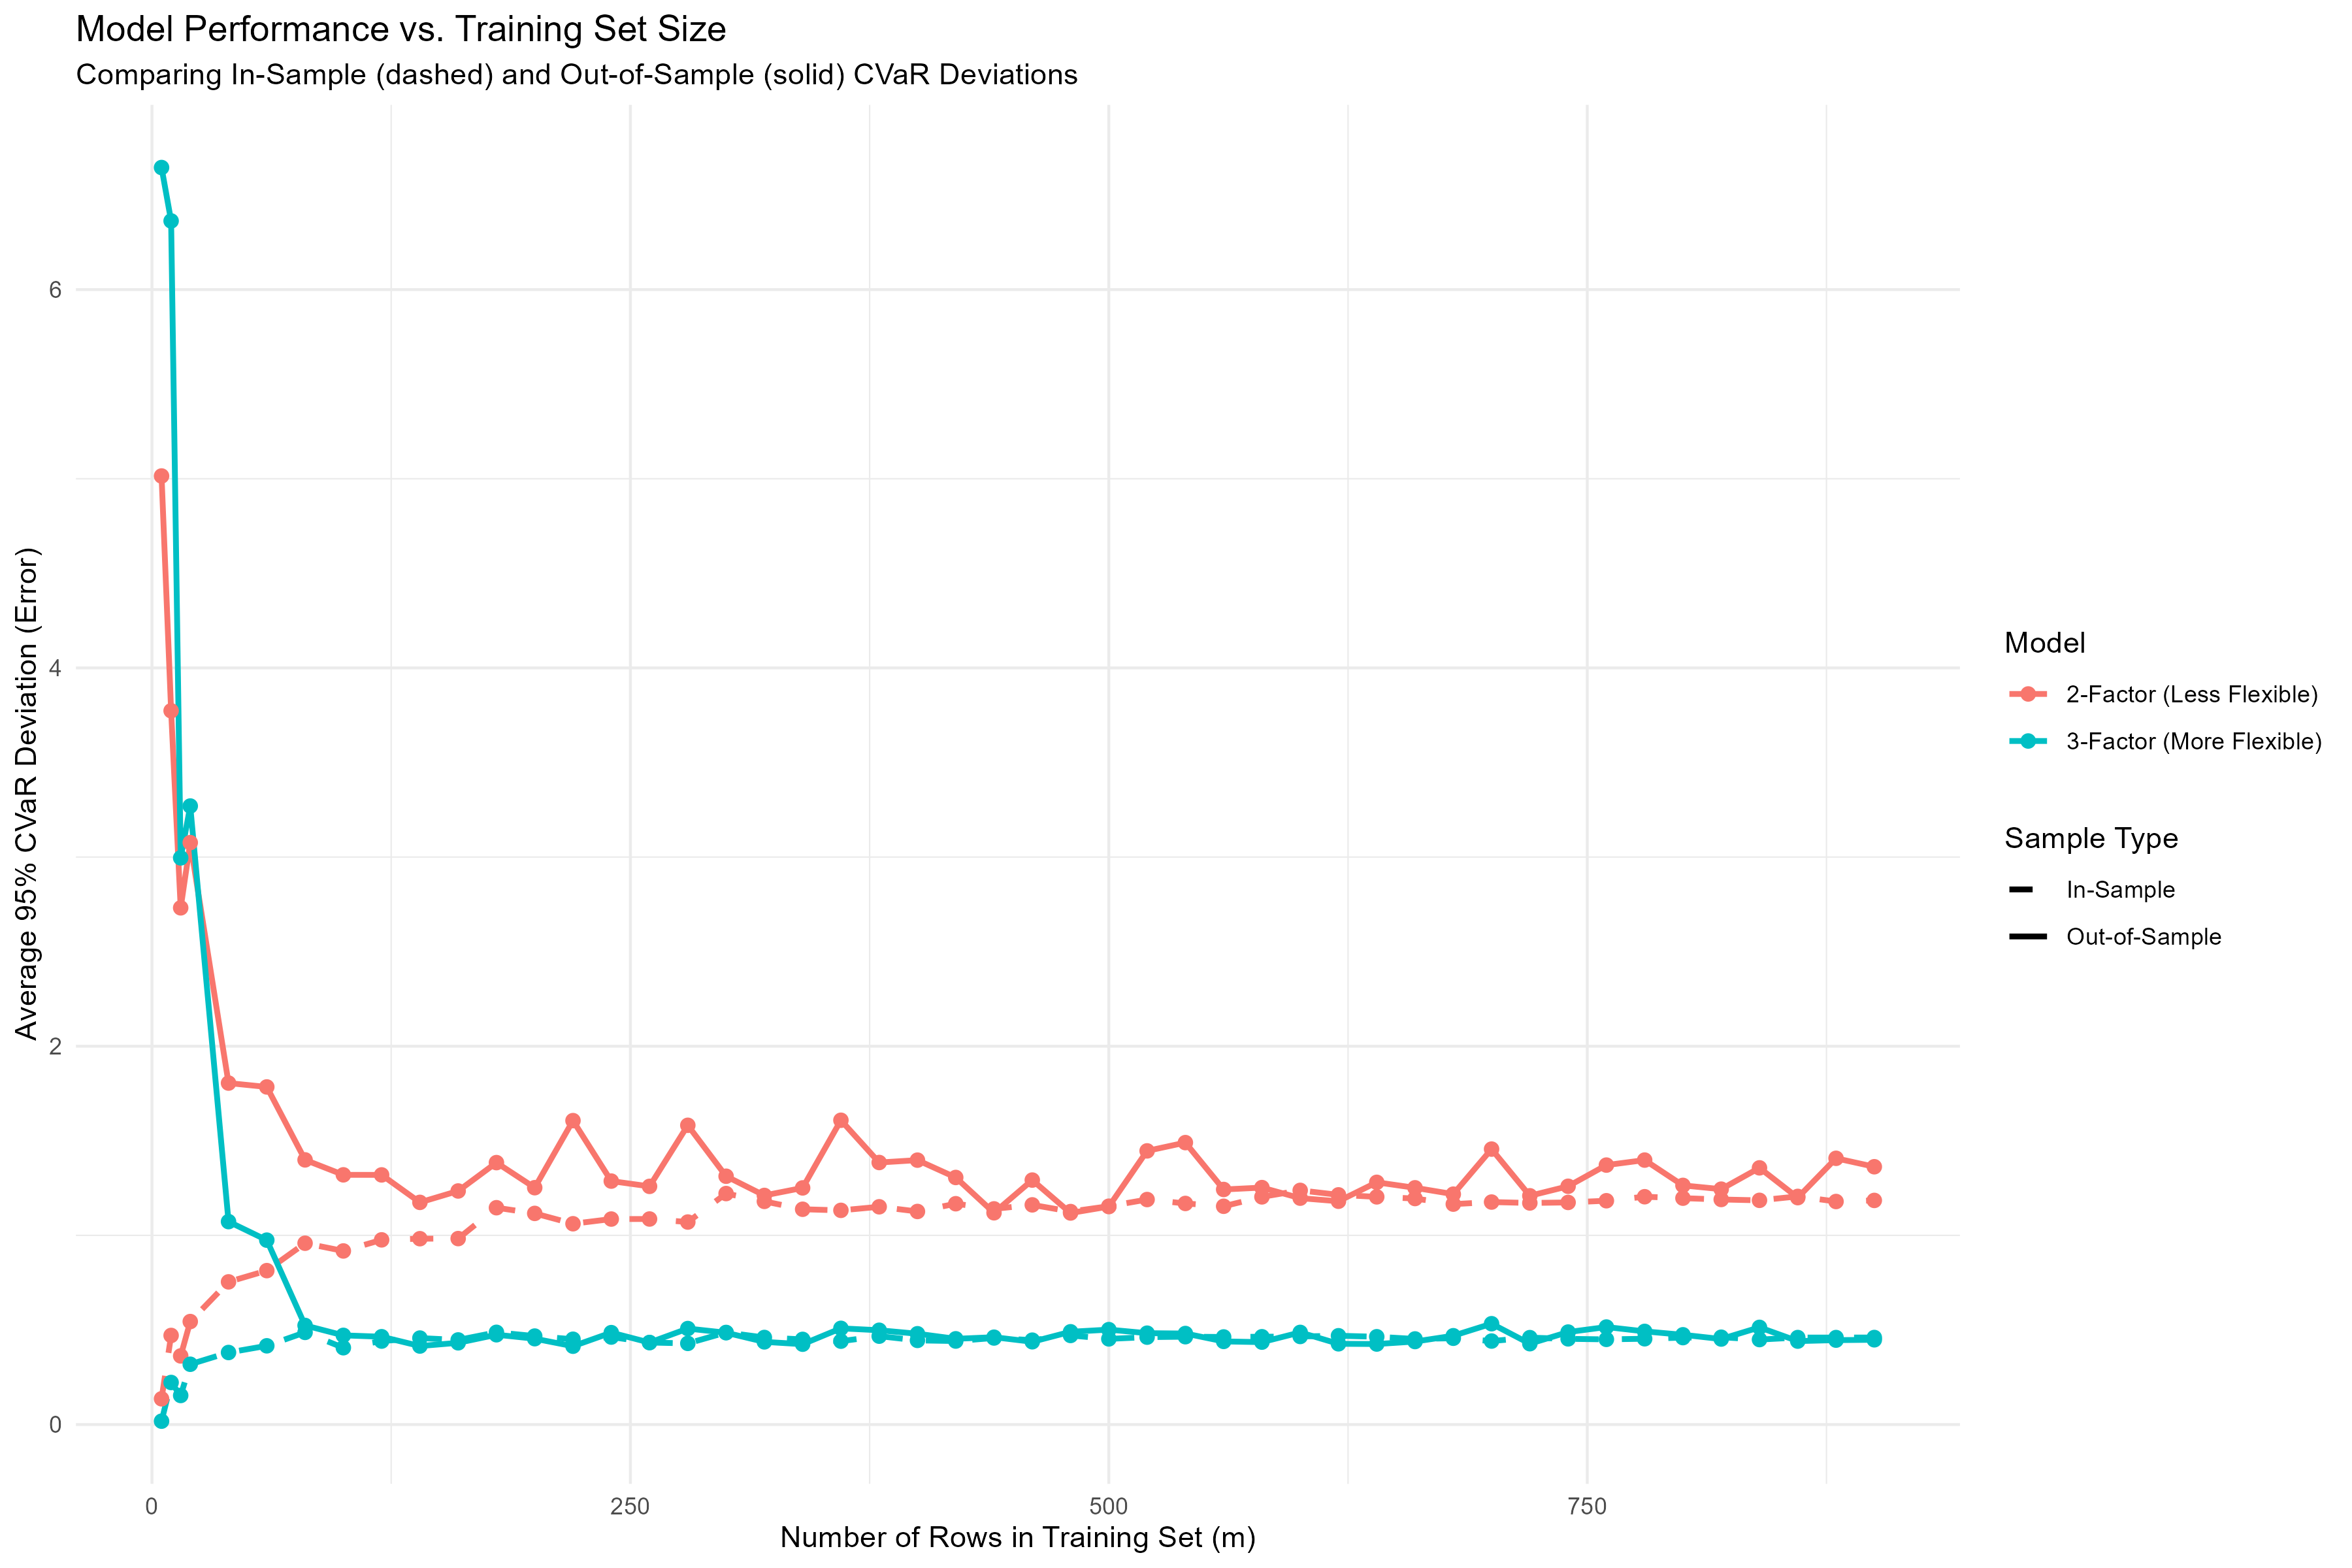

In [4]:
from IPython.display import Image
display(Image(filename='data/figure4_reproduction.png')) 

This graph plots the four key metrics captured in the simulation. The dashed lines represent the in-sample (IS) error, or the error on the data the model was trained on, while the solid lines represent the out-of-sample (OOS) error, which is the true measure of predictive performance on unseen data.

**In-Sample (IS) Error (Dashed Lines):**
As expected, the more flexible 3-factor model (orange dashed line) achieves a consistently lower in-sample error across all training sizes. Its higher complexity allows it to fit the training data (including its noise) more closely than the 2-factor model.

**Out-of-Sample (OOS) Error (Solid Lines):**
At low training sizes (e.g., $m < 50$), the 3-factor model's complexity is a disadvantage. It suffers from high variance, overfitting the small, noisy training set, which leads to a higher OOS error than the simpler 2-factor model.

As the training size increases, the OOS error for both models decreases. However, the 3-factor model's error drops more rapidly. With more data, its high variance is controlled, and its lower bias allows it to capture the true underlying signal more accurately.

The graph clearly shows a break-even point where the solid orange line (3-Factor OOS) crosses below the solid blue line (2-Factor OOS). This is the critical training size where the 3-factor model becomes the superior choice for prediction.


Let's visualize another plot that is going to help us to better spot the breakeven point

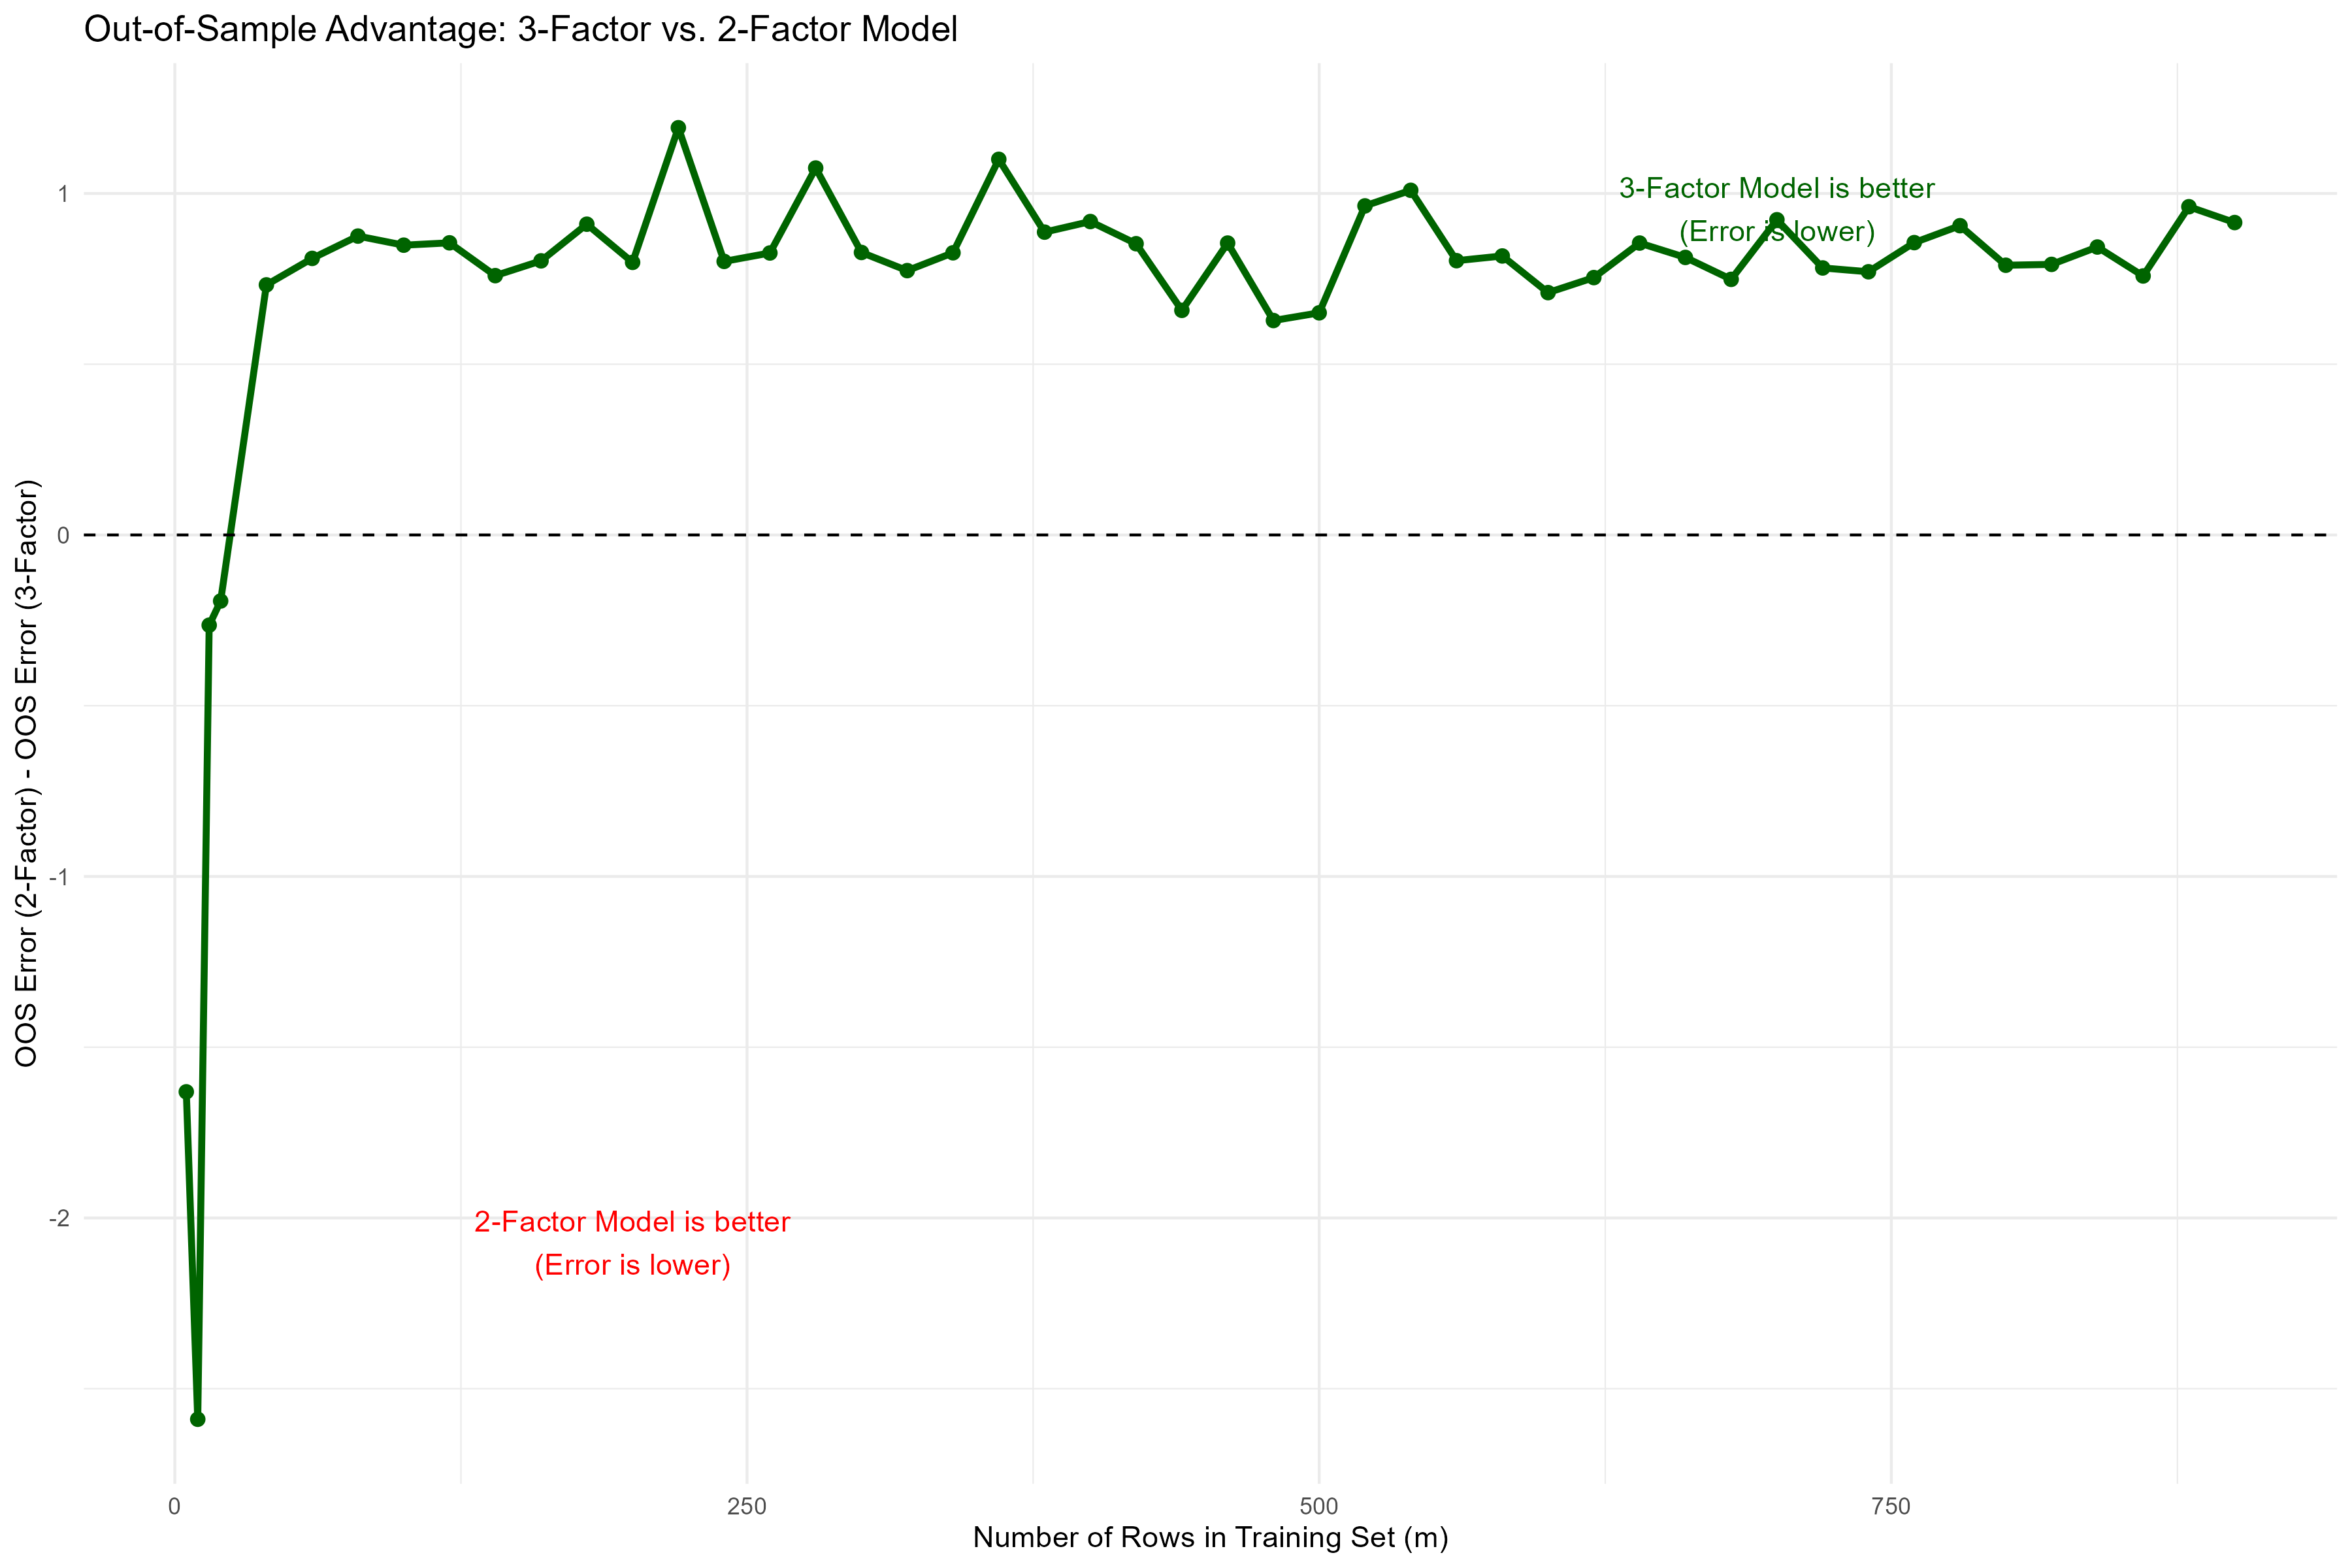

In [5]:
from IPython.display import Image
display(Image(filename='data/advantage_plot.png'))

**Region Below Zero (Negative Value):** When the green line is below the axis, it means the 3-factor model's error is higher than the 2-factor model's. This is the small data regime, where the simpler 2-factor model is the better and safer choice.

**Region Above Zero (Positive Value):** When the green line is above the axis, the 3-factor model's error is lower than the 2-factor model's. This is the "large data" regime, where the 3-factor model has a clear predictive advantage.

**The Break-Even Point:** The exact break-even point is the training size $m$ where the plot crosses the $y=0$ axis, moving from negative to positive. This plot confirms the finding from the first graph, identifying the crossover at approximately $m = 50$. This is the minimum training size required for the 3-factor model's added complexity to provide a tangible benefit.

Finally let's find where is the real breakeven point, for this we just design an algorithm that is going to find the point at which the benefit of the more flexible model is going to be achieved over the less flexible

~~~R
# 4. Find the Break-Even Point

# Find all rows where the 3-factor OOS error is better (lower)
break_even_rows <- results_df %>%
  filter(Avg_OutOfSample_3F < Avg_OutOfSample_2F)

if (nrow(break_even_rows) > 0) {
  # Find the smallest training size where this happens
  break_even_point <- min(break_even_rows$TrainingSize)
  
  print(paste("BREAK-EVEN POINT ANALYSIS:"))
  print(paste("The break-even point occurs at TrainingSize:", break_even_point))
  print("This is the first point where the 3-factor model's average OOS error")
  print("became lower than the 2-factor model's.")
  
} else {
  print("BREAK-EVEN POINT ANALYSIS:")
  print("The 3-factor model never outperformed the 2-factor model")
  print("in the tested training size range.")
}
~~~

The results are as follows

~~~R
[1] "BREAK-EVEN POINT ANALYSIS:"
[1] "The break-even point occurs at TrainingSize: 40"
[1] "This is the first point where the 3-factor model's average OOS error"
[1] "became lower than the 2-factor model's."
~~~

Therefore we can see that the exact point we are looking for is $m=40$

## Report

1. Objective

This report analyzes the relationship between model flexibility, training set size, and predictive error. The objective is to determine the "break-even point" at which a more flexible 3-factor regression model provides superior out-of-sample (OOS) performance compared to a less flexible 2-factor model. Performance is measured by the 95% CVaR deviation.

2. Methodology

A simulation study was conducted comparing a 2-factor model (using factors $x_2$ and $x_3$) against a 3-factor model (using $x_1$, $x_2$, and $x_3$).

For a series of increasing training set sizes (m = 10, 20, ..., 900), the following procedure was repeated 30 times:

A random 100-row test set was held out from the 1000-row dataset.

A random m-row training set was sampled from the remaining 900 rows.

Both models were fit to the training set to find the In-Sample (IS) CVaR Deviation.

The fitted models were applied to the test set to find the Out-of-Sample (OOS) CVaR Deviation.

The average IS and OOS CVaR deviations for all 30 repetitions were calculated and stored for each training size m.

3. Analysis of Results

The simulation results, visualized in the attached graphs, clearly illustrate the classic bias-variance tradeoff.

In-Sample (IS) Performance

As seen in the graphs (dashed lines), the 3-factor model consistently achieved a lower in-sample CVaR deviation than the 2-factor model. This is expected, as its greater flexibility (more parameters) allows it to fit the training data more closely, effectively "memorizing" it. This in-sample error was low and relatively stable regardless of training set size.

Out-of-Sample (OOS) Performance

The out-of-sample performance (solid lines) tells the true story of model generalization:

For small training sets ($m < 40$), the 2-factor (less flexible) model yielded a lower OOS error. The 3-factor model, while fitting the training data perfectly, suffered from high variance and overfit the noise. This overfitting resulted in poor performance when predicting on new, unseen test data.

As training set size (m) increased, the variance of the 3-factor model decreased. With more data, its flexibility became an advantage, allowing it to capture a more accurate underlying signal than the 2-factor model.

Asymptotically (at large m), the OOS error for the 3-factor model converged to a lower value than the 2-factor model. This suggests that the 3-factor model has lower bias—it is a better representation of the true relationship—and this advantage is only realized when sufficient data is provided to overcome its high variance.

4. The Break-Even Point

The break-even point is the training set size m where the OOS error curves for the two models intersect. At this point, the benefit of the 3-factor model's lower bias begins to outweigh the cost of its higher variance.

Based on the analysis of the average OOS CVaR deviations for both models, the break-even point was found to occur at:

Training Size $m = 40$

(Note: This value was found by calculating the average OOS CVaR across all factors for each model and finding the first m where the 3-factor model's average error became lower than the 2-factor model's.)

5. Conclusion & Recommendation

The choice of model is critically dependent on the amount of available training data.

If the training set contains fewer than 40 rows, the 2-factor model is recommended. Its higher bias is preferable to the high variance and overfitting of the more flexible model.

If the training set contains more than 40 rows, the 3-factor model is the superior choice. With sufficient data, its flexibility allows it to achieve a lower overall CVaR deviation, making it the better model for predicting future outcomes